In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

In [3]:
path_dolar = r"C:\Users\lucas.takabayashi\Desktop\GitHub\agro-analysis\data\dolar.xlsx"
path_milho = r"C:\Users\lucas.takabayashi\Desktop\GitHub\agro-analysis\data\milho.xlsx"
path_soja = r"C:\Users\lucas.takabayashi\Desktop\GitHub\agro-analysis\data\soja.xlsx"


In [9]:
df_teste = pd.read_excel(path_dolar)

In [4]:
def tratamento_dados(caminho, header=1):

    #Lendo arquivo e padronizando colunas e casas decimais
    df = pd.read_excel(caminho, header=header, decimal=',')

    #Padronizando colunas
    df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_')

    #Convertendo data
    df['data'] = pd.to_datetime(df['data'], format='%d/%m/%Y')
    df['ano'] = df['data'].dt.year.astype('int')
    df['mes'] = df['data'].dt.month.astype('int')
    df['ano_mes'] = df['data'].dt.to_period('M')

    return df

In [5]:
df_dolar = tratamento_dados(path_dolar,header=3)
df_milho = tratamento_dados(path_milho,header=3)
df_soja = tratamento_dados(path_soja,header=3)

In [36]:
print(
    f'df_dolar colunas: {list(df_dolar.columns)} \n'
    f'df_soja  colunas: {list(df_soja.columns)} \n'
    f'df_milho colunas: {list(df_milho.columns)} \n'
)

df_dolar colunas: ['data', 'à_vista_r$', 'ano', 'mes', 'ano_mes'] 
df_soja  colunas: ['data', 'à_vista_r$', 'à_vista_us$', 'ano', 'mes', 'ano_mes'] 
df_milho colunas: ['data', 'à_vista_r$', 'à_vista_us$', 'ano', 'mes', 'ano_mes'] 



['data', 'à_vista_r$', 'ano', 'mes', 'ano_mes']

In [6]:
df_soja.head()

,data,à_vista_r$,à_vista_us$,ano,mes,ano_mes
0,2020-01-02,82.92,20.61,2020,1,2020-01
1,2020-01-03,83.01,20.48,2020,1,2020-01
2,2020-01-06,82.83,20.35,2020,1,2020-01
3,2020-01-07,82.81,20.40,2020,1,2020-01
4,2020-01-08,82.95,20.49,2020,1,2020-01


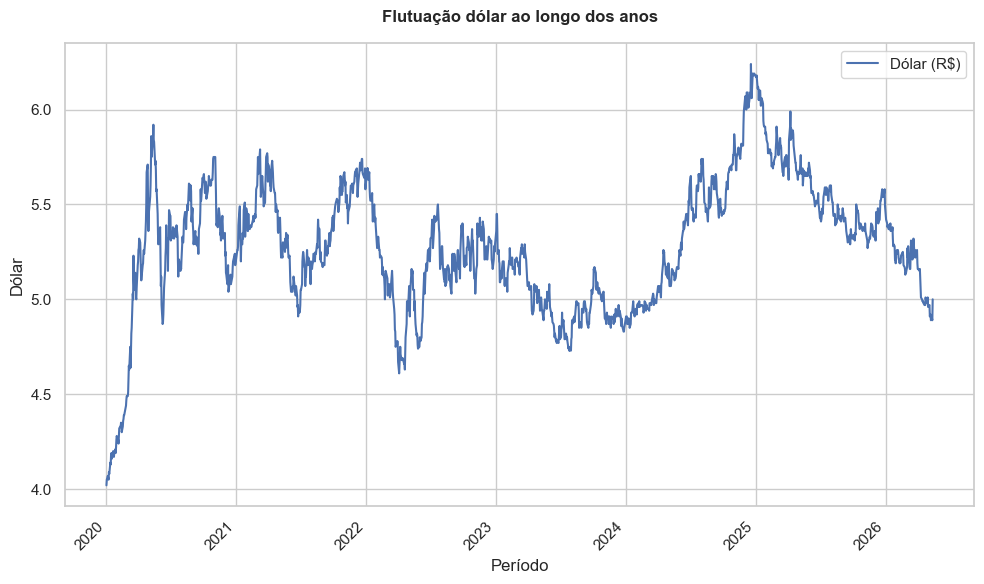

In [ ]:
plt.figure(figsize=(10,6))
sns.lineplot(
    x=df_dolar['data'],
    y=df_dolar['dolar'],
    label='Dólar (R$)',
    linewidth=1.5)

plt.title('Flutuação dólar ao longo dos anos', fontweight='bold', pad=15)
plt.xlabel('Período')
plt.ylabel('Dólar')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()